<a href="https://colab.research.google.com/github/jopraetaro-1/Air-Quality-AI-Project/blob/main/CO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/air+quality/AirQualityUCI.csv', sep=';')
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578",NaN,NaN
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255",NaN,NaN
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502",NaN,NaN
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867",NaN,NaN
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888",NaN,NaN


In [2]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 9471 entries, ('10/03/2004;18.00.00;2', '6;1360;150;11', '9;1046;166;1056;113;1692;1268;13', '6;48', '9;0') to (';;;;;;;;;;;;;;;;', nan, nan, nan, nan)
Data columns (total 1 columns):
 #   Column                                                                                                                        Non-Null Count  Dtype 
---  ------                                                                                                                        --------------  ----- 
 0   Date;Time;CO(GT);PT08.S1(CO);NMHC(GT);C6H6(GT);PT08.S2(NMHC);NOx(GT);PT08.S3(NOx);NO2(GT);PT08.S4(NO2);PT08.S5(O3);T;RH;AH;;  6915 non-null   object
dtypes: object(1)
memory usage: 1.2+ MB


In [6]:
#Selecting Variables to Predict CO
df = df[['CO(GT)','T','RH','NO2(GT)','NOx(GT)','C6H6(GT)']]
df = df.dropna()


In [8]:
df = df.replace(',', '.', regex=True)
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna()

In [9]:
#Using Linear Regression Model to Predict
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['T','RH','NO2(GT)','NOx(GT)','C6H6(GT)']]
y = df['CO(GT)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

In [10]:
#R2 Score

from sklearn.metrics import r2_score

r2_score(y_test, pred)

0.4457887193424084

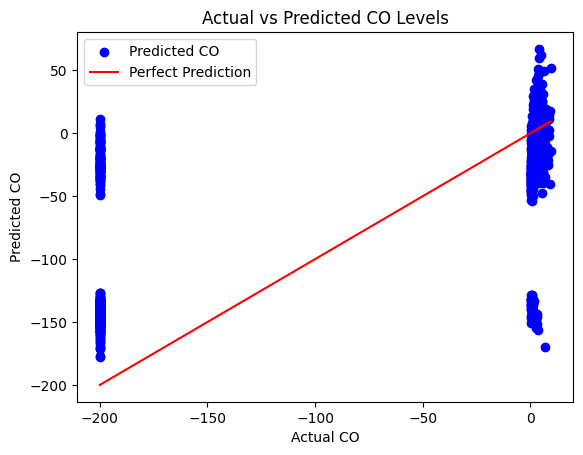

In [12]:
#Actual CO vs Predict CO
import matplotlib.pyplot as plt

plt.figure()

# จุด prediction
plt.scatter(y_test, pred, color='blue', label='Predicted CO')

# เส้น perfect prediction (เส้นตรง y = x)
plt.plot(y_test, y_test, color='red', label='Perfect Prediction')

plt.xlabel("Actual CO")
plt.ylabel("Predicted CO")
plt.title("Actual vs Predicted CO Levels")

plt.legend()
plt.show()

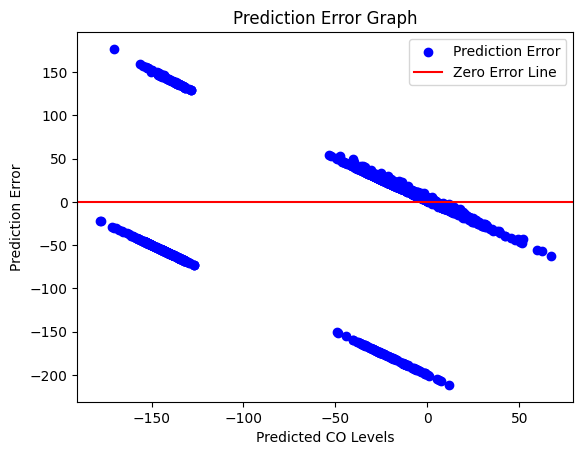

In [15]:
#Prediction Error Graph
import matplotlib.pyplot as plt

# คำนวณ error
error = y_test - pred

plt.figure()

# จุด error
plt.scatter(pred, error, color='blue', label='Prediction Error')

# เส้น error = 0
plt.axhline(0, color='red', label='Zero Error Line')

plt.xlabel("Predicted CO Levels")
plt.ylabel("Prediction Error")
plt.title("Prediction Error Graph")

plt.legend()
plt.show()

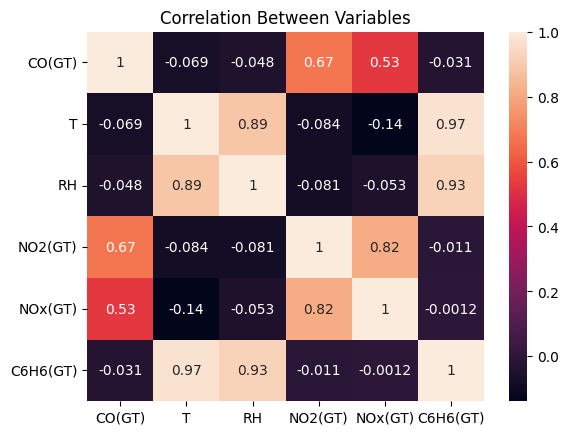

In [16]:
#Correlation Graph
import seaborn as sns

sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Between Variables")
plt.show()

In [17]:
from IPython.display import display, HTML

html_code = """
<!DOCTYPE html>
<html>
<head>
<title>Air Quality Prediction</title>
<style>
body {font-family: Arial; background:#f4f6f8; text-align:center; padding:40px;}
.box {background:white; padding:30px; width:400px; margin:auto; border-radius:10px; box-shadow:0 0 10px rgba(0,0,0,0.1);}
input {width:90%; padding:10px; margin:10px;}
button {background:#007bff; color:white; padding:12px; border:none; width:95%; font-size:16px; border-radius:5px;}
</style>
</head>
<body>

<div class="box">
<h2>Air Quality Prediction</h2>

<input type="number" id="temp" placeholder="Temperature (T)">
<input type="number" id="humidity" placeholder="Humidity (RH)">
<input type="number" id="no2" placeholder="NO2 Level">
<input type="number" id="nox" placeholder="NOx Level">
<input type="number" id="benzene" placeholder="Benzene Level">

<button onclick="predict()">Predict CO Level</button>

<h3 id="result"></h3>
</div>

<script>
function predict() {

let T = document.getElementById("temp").value;
let RH = document.getElementById("humidity").value;
let NO2 = document.getElementById("no2").value;
let NOx = document.getElementById("nox").value;
let C6H6 = document.getElementById("benzene").value;

// ตัวอย่าง model (เอาไว้โชว์ใน assignment)
let CO = 0.5*T + 0.2*RH + 0.3*NO2 + 0.4*NOx + 0.6*C6H6;

document.getElementById("result").innerHTML =
"Predicted CO Level = " + CO.toFixed(2);
}
</script>

</body>
</html>
"""

display(HTML(html_code))